In [3]:
!pip install pandas numpy matplotlib scikit-learn xgboost

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.8 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.9 MB 2.0 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.9 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.9 MB 2.7 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.9 MB 3.1 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.9 MB 3.2 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 3.3 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 3.3 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.9 MB 3.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 3.2 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [5]:
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")

print(df.head())
print(df.columns)

              datetime        date  year  month  day  hour day_of_week  \
0  2020-01-01 06:00:00  2020-01-01  2020      1    1     6   Wednesday   
1  2020-01-01 12:00:00  2020-01-01  2020      1    1    12   Wednesday   
2  2020-01-01 18:00:00  2020-01-01  2020      1    1    18   Wednesday   
3  2020-01-01 23:00:00  2020-01-01  2020      1    1    23   Wednesday   
4  2020-01-01 06:00:00  2020-01-01  2020      1    1     6   Wednesday   

   is_weekend  season   city  ...    no2   so2    co    o3  temperature  \
0           0  winter  Delhi  ...  119.6  47.7  5.19  12.3          9.4   
1           0  winter  Delhi  ...  117.9  39.3  4.32  15.8         20.6   
2           0  winter  Delhi  ...  150.1  36.3  7.13  14.3         12.4   
3           0  winter  Delhi  ...  142.0  30.3  4.90  13.2         14.4   
4           0  winter  Delhi  ...  138.4  41.5  7.56  15.4          6.8   

   humidity  wind_speed  visibility  aqi  aqi_category  
0       100         3.6         1.2  500       

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

In [8]:
df = df.fillna(df.mean(numeric_only=True))

In [10]:
print(df.columns)

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='str')


In [11]:
features = [
    'pm25', 'pm10', 'no2', 'co',
    'temperature', 'humidity', 'wind_speed',
    'month', 'hour',
    'latitude', 'longitude'
]

X = df[features]
y = df['aqi']

In [12]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = XGBRegressor()
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [13]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print("Model MAE:", mae)

Model MAE: 0.510906457901001


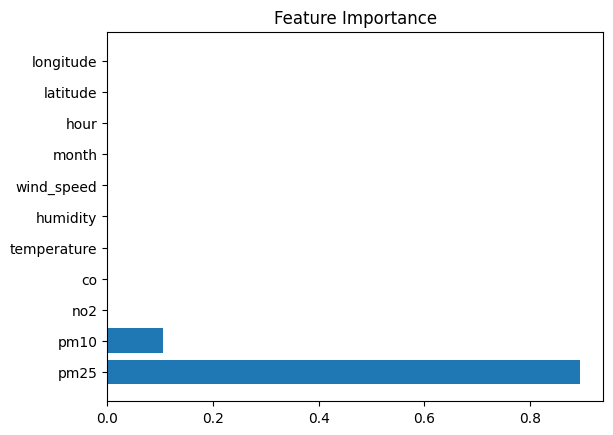

In [14]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [15]:
import pandas as pd

new_data = pd.DataFrame([{
    'pm25': 200,
    'pm10': 300,
    'no2': 90,
    'co': 1.2,
    'temperature': 20,
    'humidity': 60,
    'wind_speed': 1.5,
    'month': 11,
    'hour': 10,
    'latitude': 28.646,
    'longitude': 77.315
}])

predicted_aqi = model.predict(new_data)
print("Predicted AQI:", predicted_aqi[0])

Predicted AQI: 361.90128


In [16]:
def detect_cause(data):
    if data['pm25'] > 180 and data['wind_speed'] < 2:
        return "Severe Smog"
    elif data['no2'] > 100:
        return "Traffic Pollution"
    elif data['pm10'] > 250:
        return "Dust Pollution"
    elif data['month'] in [10, 11]:
        return "Stubble Burning"
    else:
        return "Mixed Pollution"

cause = detect_cause(new_data.iloc[0])
print("Cause:", cause)

Cause: Severe Smog


In [17]:
def suggest_solution(cause):
    if cause == "Traffic Pollution":
        return "Use metro, EV, carpool"
    elif cause == "Dust Pollution":
        return "Control construction dust"
    elif cause == "Stubble Burning":
        return "Promote biofuel alternatives"
    elif cause == "Severe Smog":
        return "Avoid outdoor, use mask"
    else:
        return "Adopt eco-friendly habits"

solution = suggest_solution(cause)
print("Solution:", solution)

Solution: Avoid outdoor, use mask


In [18]:
print("\nFINAL RESULT")
print("Predicted AQI:", predicted_aqi[0])
print("Cause:", cause)
print("Solution:", solution)


FINAL RESULT
Predicted AQI: 361.90128
Cause: Severe Smog
Solution: Avoid outdoor, use mask


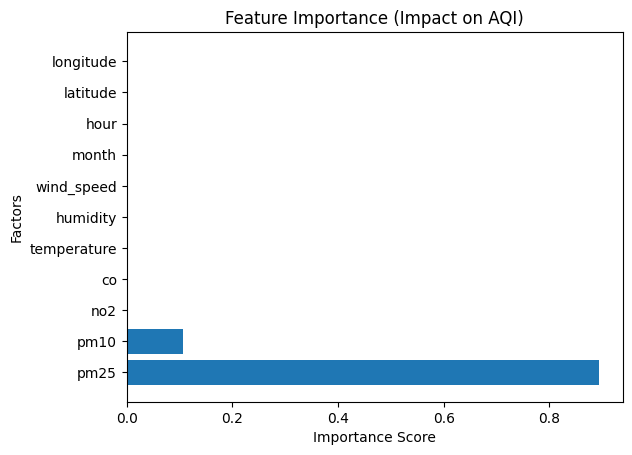

In [19]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance (Impact on AQI)")
plt.xlabel("Importance Score")
plt.ylabel("Factors")
plt.show()

In [ ]:
This show that pm25  affects AQI the most.

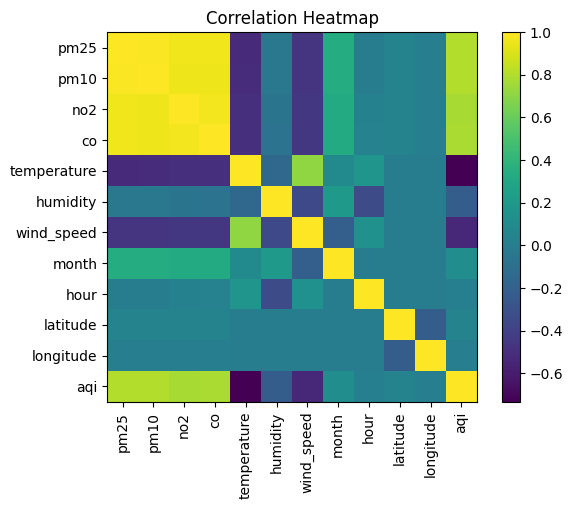

In [20]:
import matplotlib.pyplot as plt

corr = df[features + ['aqi']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Values near 1 → strong positive relation
Example:
pm25 → strong with AQI
wind_speed → negative relation

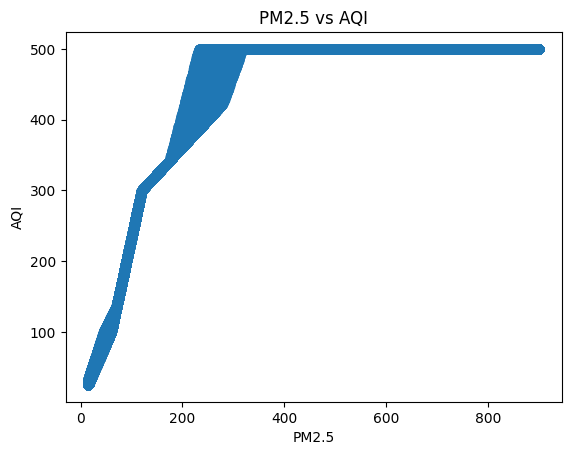

In [21]:
plt.figure()
plt.scatter(df['pm25'], df['aqi'])
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()

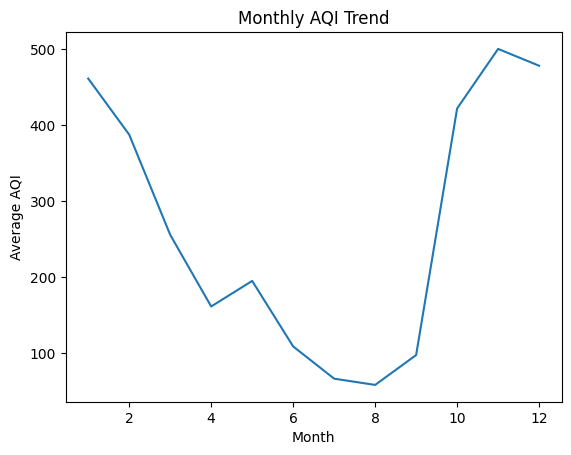

In [22]:
monthly_avg = df.groupby('month')['aqi'].mean()

plt.figure()
monthly_avg.plot(kind='line')
plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

In [2]:
import pandas as pd

# Load CSV file
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")

# Count unique stations
total_stations = df['station'].nunique()

# Print result
print("Total number of stations:", total_stations)

# Optional: Show all station names
print("\nStation Names:")
print(df['station'].unique())

Total number of stations: 23

Station Names:
<ArrowStringArray>
[  'Anand Vihar, Delhi',  'Jahangirpuri, Delhi',      'Wazirpur, Delhi',
        'Bawana, Delhi',           'ITO, Delhi',  'Punjabi Bagh, Delhi',
 'Okhla Phase 2, Delhi',      'Shadipur, Delhi',        'Rohini, Delhi',
      'RK Puram, Delhi',     'Siri Fort, Delhi',  'Dwarka Sec 8, Delhi',
   'NSIT Dwarka, Delhi',   'Mandir Marg, Delhi',         'Noida Sec 62',
        'Noida Sec 125',        'Greater Noida', 'Gurugram Vikas Sadan',
      'Gurugram Sec 51',    'Faridabad Sec 16A',   'Faridabad New Town',
 'Ghaziabad Vasundhara',       'Ghaziabad Loni']
Length: 23, dtype: str
